In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from models.logistic_regression import LogisticRegressionModel
from models.xgboost_model import XGBoostModel
from evaluation.shap_explainer import SHAPExplainer
from models.lightgbm_model import LightGBMModel
import shap
import torch
from models.mlp_model import MLPModel
import joblib
import importlib
import models.predictor as predictor_module
import json
from sklearn.metrics import confusion_matrix
import sklearn

print("sklearn:", sklearn.__version__)

sklearn: 1.8.0


In [2]:
FEATURE_PATH = PROJECT_ROOT / "data" / "processed" / "model_features"

X_train = pd.read_pickle(FEATURE_PATH / "X_train.pkl")
X_validation = pd.read_pickle(FEATURE_PATH / "X_validation.pkl")
y_train = pd.read_pickle(FEATURE_PATH / "y_train.pkl")
y_validation = pd.read_pickle(FEATURE_PATH / "y_validation.pkl")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)

X_train: (472432, 36)
X_validation: (118108, 36)
y_train: (472432,)
y_validation: (118108,)


In [3]:
print("Train fraud rate:", y_train.mean())
print("Validation fraud rate:", y_validation.mean())

Train fraud rate: 0.03513521522674162
Validation fraud rate: 0.034409184813899145


# Class weights

In [4]:
fraud_count = (y_train == 1).sum()
legitimate_count = (y_train == 0).sum()
scale_ratio = legitimate_count / fraud_count

print("Legitimate transactions:", legitimate_count)
print("Fraud transactions:", fraud_count)
print("Fraud rate:", y_train.mean())
print("Class ratio:", scale_ratio)

Legitimate transactions: 455833
Fraud transactions: 16599
Fraud rate: 0.03513521522674162
Class ratio: 27.46147358274595


# Instantiate the baseline model

In [5]:
model = LogisticRegressionModel()
model.train(X_train, y_train)
print("Logistic Regression training completed.")

Logistic Regression training completed.


# Fraud probabilities

In [6]:
y_validation_proba = model.predict_proba(X_validation)

print("Predictions generated:", len(y_validation_proba))
print("Minimum probability:", y_validation_proba.min())
print("Maximum probability:", y_validation_proba.max())

Predictions generated: 118108
Minimum probability: 0.08266714421141848
Maximum probability: 0.989088311377228


In [7]:
pr_auc = average_precision_score(y_validation, y_validation_proba)
roc_auc = roc_auc_score(y_validation, y_validation_proba)

print("PR-AUC:", pr_auc)
print("ROC-AUC:", roc_auc)

PR-AUC: 0.15376192525260063
ROC-AUC: 0.748676288378957


# Threshold evaluation

In [8]:
threshold = 0.5
y_validation_pred = (y_validation_proba >= threshold).astype(int)

print("Precision:", precision_score(y_validation, y_validation_pred))
print("Recall:", recall_score(y_validation, y_validation_pred))
print("F1:", f1_score(y_validation, y_validation_pred))
print(confusion_matrix(y_validation, y_validation_pred))

Precision: 0.06953410217354512
Recall: 0.7076771653543307
F1: 0.12662630709961475
[[75559 38485]
 [ 1188  2876]]


In [9]:
baseline_results = {
    "model": "Logistic Regression",
    "pr_auc": pr_auc,
    "roc_auc": roc_auc,
    "precision": precision_score(y_validation, y_validation_pred),
    "recall": recall_score(y_validation, y_validation_pred),
    "f1": f1_score(y_validation, y_validation_pred),
    "threshold": 0.5,
}
baseline_results

{'model': 'Logistic Regression',
 'pr_auc': 0.15376192525260063,
 'roc_auc': 0.748676288378957,
 'precision': 0.06953410217354512,
 'recall': 0.7076771653543307,
 'f1': 0.12662630709961475,
 'threshold': 0.5}

In [10]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results = []

for t in thresholds:
    p = (y_validation_proba >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_validation, p),
        "recall": recall_score(y_validation, p),
        "f1": f1_score(y_validation, p),
    })

threshold_results = pd.DataFrame(threshold_results).sort_values("f1", ascending=False).reset_index(drop=True)
threshold_results

,threshold,precision,recall,f1
0,0.8,0.158981,0.331693,0.214941
1,0.9,0.272537,0.159941,0.201582
2,0.7,0.122193,0.479331,0.194742
3,0.6,0.092019,0.589813,0.159200
4,0.5,0.069534,0.707677,0.126626
5,0.4,0.050070,0.835630,0.094479
6,0.3,0.037681,0.969488,0.072543
7,0.2,0.034506,0.999754,0.066709
8,0.1,0.034409,1.000000,0.066530


## Threshold Analysis Insight

- Increasing the decision threshold improves precision but reduces recall.
- At threshold 0.5, recall is high (70.8%) but precision is low (7.0%).
- Among the tested thresholds, 0.8 gives the highest F1 (~0.215), with
  precision ~15.9% and recall ~33.2%.
- Threshold selection represents a trade-off between catching more fraud
  and reducing false alerts.

# Xgboost

In [11]:
xgb_model = XGBoostModel(scale_pos_weight=scale_ratio)
xgb_model.train(X_train, y_train, X_validation, y_validation)
print("XGBoost training completed.")

XGBoost training completed.


In [12]:
y_validation_proba_xgb = xgb_model.predict_proba(X_validation)

print("Predictions generated:", len(y_validation_proba_xgb))
print("Minimum probability:", y_validation_proba_xgb.min())
print("Maximum probability:", y_validation_proba_xgb.max())

Predictions generated: 118108
Minimum probability: 0.003923498
Maximum probability: 0.9813318


In [13]:
pr_auc_xgb = average_precision_score(y_validation, y_validation_proba_xgb)
roc_auc_xgb = roc_auc_score(y_validation, y_validation_proba_xgb)

print("XGBoost PR-AUC:", pr_auc_xgb)
print("XGBoost ROC-AUC:", roc_auc_xgb)

XGBoost PR-AUC: 0.21038871626723102
XGBoost ROC-AUC: 0.8097400042983134


In [14]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
xgb_threshold_results = []

for t in thresholds:
    p = (y_validation_proba_xgb >= t).astype(int)
    xgb_threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_validation, p),
        "recall": recall_score(y_validation, p),
        "f1": f1_score(y_validation, p),
    })

xgb_threshold_results = pd.DataFrame(xgb_threshold_results).sort_values("f1", ascending=False).reset_index(drop=True)
xgb_threshold_results

,threshold,precision,recall,f1
0,0.7,0.251693,0.329232,0.285288
1,0.6,0.203697,0.428396,0.276108
2,0.8,0.325774,0.222687,0.264543
3,0.5,0.154130,0.544045,0.240209
4,0.4,0.110016,0.656496,0.188451
5,0.3,0.076171,0.786417,0.138890
6,0.9,0.472103,0.081201,0.138568
7,0.2,0.054241,0.901083,0.102322
8,0.1,0.040988,0.974902,0.078668


In [15]:
xgb_threshold = 0.7
y_validation_pred_xgb = (y_validation_proba_xgb >= xgb_threshold).astype(int)

print(confusion_matrix(y_validation, y_validation_pred_xgb))
print("Precision:", precision_score(y_validation, y_validation_pred_xgb))
print("Recall:", recall_score(y_validation, y_validation_pred_xgb))
print("F1:", f1_score(y_validation, y_validation_pred_xgb))

[[110066   3978]
 [  2726   1338]]
Precision: 0.2516930022573363
Recall: 0.32923228346456695
F1: 0.28528784648187633


In [16]:
feature_importance = pd.Series(
    xgb_model.model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)

ProductCD_C               0.442929
DeviceType_MISSING        0.072764
card6_debit               0.045713
DeviceType_mobile         0.039045
D7_missing                0.036942
card6_credit              0.035233
ProductCD_S               0.025487
ProductCD_W               0.024975
ProductCD_H               0.022527
D14_missing               0.021104
ProductCD_R               0.016675
log_transaction_amount    0.016450
D12_missing               0.016449
card4_discover            0.015039
TransactionAmt            0.014144
dtype: float32

# XGBoost Feature Importance Insight
----------------------------------

- ProductCD_C is the dominant feature in the baseline XGBoost model
  (importance ≈ 0.443).
- DeviceType_MISSING, card6 categories and several missingness indicators
  are also among the strongest features.
- Transaction amount features contribute to the model but have much lower
  importance than ProductCD_C.
- Entity and relationship features do not appear in the top 15 by the
  built-in XGBoost importance measure.
- Feature importance indicates model usage, not causality or fraud direction.
- The contribution of feature groups should therefore be validated through
  controlled ablation experiments before removing any engineered features.

# Feature-group ablation.

In [17]:
transaction_features = ["TransactionAmt", "TransactionDT", "log_transaction_amount"]
missingness_features = ["addr1_missing", "addr2_missing", "D7_missing", "D12_missing", "D13_missing", "D14_missing", "DeviceInfo_missing"]
temporal_features = ["time_since_previous_transaction", "has_previous_transaction"]
entity_features = ["card1_transaction_count", "card2_transaction_count", "addr1_transaction_count"]
relationship_features = ["card1_DeviceInfo_transaction_count", "card1_unique_DeviceInfo_count", "DeviceInfo_unique_card1_count"]
categorical_encoded_features = [
    c for c in X_train.columns
    if c.startswith(("ProductCD_", "card4_", "card6_", "DeviceType_"))
]

print("Transaction:", len(transaction_features))
print("Missingness:", len(missingness_features))
print("Temporal:", len(temporal_features))
print("Entity:", len(entity_features))
print("Relationship:", len(relationship_features))
print("Categorical:", len(categorical_encoded_features))

Transaction: 3
Missingness: 7
Temporal: 2
Entity: 3
Relationship: 3
Categorical: 18


In [18]:
grouped_features = (
    transaction_features + missingness_features + temporal_features +
    entity_features + relationship_features + categorical_encoded_features
)

extra_columns = [c for c in X_train.columns if c not in grouped_features]
duplicates = pd.Series(grouped_features)[pd.Series(grouped_features).duplicated()].tolist()

print("X_train columns:", len(X_train.columns))
print("Grouped features:", len(grouped_features))
print("Unaccounted columns:", extra_columns)
print("Duplicate grouped features:", duplicates)

X_train columns: 36
Grouped features: 36
Unaccounted columns: []
Duplicate grouped features: []


In [19]:
base_features = grouped_features

ablation_configs = {
    "full": base_features,
    "without_missingness": [f for f in base_features if f not in missingness_features],
    "without_temporal": [f for f in base_features if f not in temporal_features],
    "without_entity": [f for f in base_features if f not in entity_features],
    "without_relationship": [f for f in base_features if f not in relationship_features],
}

for name, features in ablation_configs.items():
    print(f"{name}: {len(features)} features")

full: 36 features
without_missingness: 29 features
without_temporal: 34 features
without_entity: 33 features
without_relationship: 33 features


In [20]:
ablation_results = []

for name, features in ablation_configs.items():
    m = XGBoostModel(scale_pos_weight=scale_ratio)
    m.train(X_train[features], y_train, X_validation[features], y_validation)
    prob = m.predict_proba(X_validation[features])

    ablation_results.append({
        "model": name,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob),
    })

ablation_results = pd.DataFrame(ablation_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
ablation_results

,model,pr_auc,roc_auc
0,full,0.210389,0.809740
1,without_temporal,0.209798,0.813691
2,without_relationship,0.207345,0.809673
3,without_missingness,0.183782,0.808942
4,without_entity,0.183122,0.779700


# Feature Ablation Insight
------------------------

- Entity features provide a strong contribution. Removing them reduces
  PR-AUC from 0.2104 to 0.1831 and ROC-AUC from 0.8097 to 0.7797.
- Missingness features are also important. Removing them reduces PR-AUC
  to 0.1838.
- Relationship features provide a smaller but measurable contribution,
  with PR-AUC decreasing from 0.2104 to 0.2073 when removed.
- Temporal features show little improvement in the current feature set.
  Removing them slightly reduces PR-AUC but increases ROC-AUC.
- Therefore, entity and missingness features are currently the strongest
  engineered feature groups, while relationship features should be
  retained and temporal features should be reconsidered during further
  development.

# XGBoost Tuning

In [21]:
depth_results = []

for depth in [3, 6, 8]:
    m = XGBoostModel(scale_pos_weight=scale_ratio, max_depth=depth)
    m.train(X_train, y_train, X_validation, y_validation)
    prob = m.predict_proba(X_validation)

    depth_results.append({
        "max_depth": depth,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob),
    })

pd.DataFrame(depth_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)

,max_depth,pr_auc,roc_auc
0,8,0.217598,0.809993
1,6,0.210389,0.809740
2,3,0.184032,0.783002


In [22]:
child_results = []

for weight in [1, 5, 10]:
    m = XGBoostModel(
        scale_pos_weight=scale_ratio,
        max_depth=8,
        min_child_weight=weight
    )
    m.train(X_train, y_train, X_validation, y_validation)
    prob = m.predict_proba(X_validation)

    child_results.append({
        "min_child_weight": weight,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob),
    })

pd.DataFrame(child_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)

,min_child_weight,pr_auc,roc_auc
0,5,0.223068,0.811618
1,1,0.217598,0.809993
2,10,0.217267,0.811858


In [23]:
learning_results = []
for lr, n in [(0.03, 500), (0.05, 300), (0.10, 200)]:
    m = XGBoostModel(
        scale_pos_weight=scale_ratio,
        n_estimators=n,
        max_depth=8,
        min_child_weight=5,
        learning_rate=lr
    )
    m.train(X_train, y_train, X_validation, y_validation)
    prob = m.predict_proba(X_validation)

    learning_results.append({
        "learning_rate": lr,
        "n_estimators": n,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob),
    })

pd.DataFrame(learning_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)

,learning_rate,n_estimators,pr_auc,roc_auc
0,0.05,300,0.223068,0.811618
1,0.03,500,0.220345,0.815191
2,0.10,200,0.206689,0.801282


# Tune subsample and colsample_bytree

In [24]:
sampling_results = []

for subsample in [0.7, 0.8, 1.0]:
    for colsample in [0.7, 0.8, 1.0]:
        m = XGBoostModel(
            scale_pos_weight=scale_ratio,
            n_estimators=300,
            max_depth=8,
            min_child_weight=5,
            learning_rate=0.05,
            subsample=subsample,
            colsample_bytree=colsample
        )
        m.train(X_train, y_train, X_validation, y_validation)
        prob = m.predict_proba(X_validation)

        sampling_results.append({
            "subsample": subsample,
            "colsample_bytree": colsample,
            "pr_auc": average_precision_score(y_validation, prob),
            "roc_auc": roc_auc_score(y_validation, prob),
        })

pd.DataFrame(sampling_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)

,subsample,colsample_bytree,pr_auc,roc_auc
0,0.8,0.8,0.223068,0.811618
1,1.0,0.7,0.220974,0.811027
2,1.0,1.0,0.219100,0.801391
3,1.0,0.8,0.217780,0.805618
4,0.7,1.0,0.217704,0.808732
5,0.8,1.0,0.216916,0.810539
6,0.7,0.7,0.214540,0.811460
7,0.8,0.7,0.213108,0.810025
8,0.7,0.8,0.211682,0.813197


# REGUALRIZATION

In [25]:
l2_results = []

for reg_lambda in [1, 5, 10]:
    m = XGBoostModel(
        scale_pos_weight=scale_ratio,
        n_estimators=300,
        max_depth=8,
        min_child_weight=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=reg_lambda
    )
    m.train(X_train, y_train, X_validation, y_validation)
    prob = m.predict_proba(X_validation)

    l2_results.append({
        "reg_lambda": reg_lambda,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob),
    })

pd.DataFrame(l2_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)

,reg_lambda,pr_auc,roc_auc
0,1,0.223068,0.811618
1,5,0.220525,0.812624
2,10,0.219292,0.815468


In [26]:
l1_results = []

for alpha in [0, 0.1, 0.5, 1]:
    m = XGBoostModel(
        scale_pos_weight=scale_ratio,
        n_estimators=300,
        max_depth=8,
        min_child_weight=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=alpha,
        reg_lambda=1
    )
    m.train(X_train, y_train, X_validation, y_validation)
    prob = m.predict_proba(X_validation)

    l1_results.append({
        "reg_alpha": alpha,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob),
    })

pd.DataFrame(l1_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)

,reg_alpha,pr_auc,roc_auc
0,0.0,0.223068,0.811618
1,0.5,0.218225,0.811257
2,0.1,0.217928,0.810161
3,1.0,0.215220,0.814024


# Scale_pos_weight

In [27]:
weight_results = []

for factor in [0.5, 1.0, 1.5, 2.0]:
    m = XGBoostModel(
        scale_pos_weight=scale_ratio * factor,
        n_estimators=300,
        max_depth=8,
        min_child_weight=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1
    )
    m.train(X_train, y_train, X_validation, y_validation)
    prob = m.predict_proba(X_validation)

    weight_results.append({
        "weight_factor": factor,
        "scale_pos_weight": scale_ratio * factor,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob),
    })

pd.DataFrame(weight_results).sort_values("pr_auc", ascending=False).reset_index(drop=True)

,weight_factor,scale_pos_weight,pr_auc,roc_auc
0,0.5,13.730737,0.226038,0.820047
1,1.0,27.461474,0.223068,0.811618
2,1.5,41.192210,0.215830,0.809800
3,2.0,54.922947,0.196878,0.800566


# Final XG boost model

In [28]:
final_xgb = XGBoostModel(
    scale_pos_weight=13.730737,
    n_estimators=300,
    max_depth=8,
    min_child_weight=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1
)
final_xgb.train(X_train, y_train, X_validation, y_validation)
print("Final XGBoost baseline trained.")

Final XGBoost baseline trained.


In [29]:
final_proba = final_xgb.predict_proba(X_validation)
final_pr_auc = average_precision_score(y_validation, final_proba)
final_roc_auc = roc_auc_score(y_validation, final_proba)

print("Predictions:", len(final_proba))
print("PR-AUC:", final_pr_auc)
print("ROC-AUC:", final_roc_auc)

Predictions: 118108
PR-AUC: 0.2260382437311778
ROC-AUC: 0.8200471285153929


In [30]:
final_threshold_results = []

for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    p = (final_proba >= t).astype(int)
    final_threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_validation, p),
        "recall": recall_score(y_validation, p),
        "f1": f1_score(y_validation, p),
    })

final_threshold_results = pd.DataFrame(final_threshold_results).sort_values("f1", ascending=False).reset_index(drop=True)
final_threshold_results

,threshold,precision,recall,f1
0,0.5,0.258030,0.355807,0.299131
1,0.4,0.210682,0.456201,0.288246
2,0.6,0.307495,0.265502,0.284960
3,0.3,0.156919,0.566437,0.245756
4,0.7,0.369870,0.181841,0.243814
5,0.2,0.104117,0.705709,0.181462
6,0.8,0.461053,0.107776,0.174711
7,0.1,0.059481,0.885089,0.111471
8,0.9,0.582979,0.033711,0.063736


## Tuned XGBoost — Threshold Analysis Insight

- The tuned XGBoost model achieved a PR-AUC of **0.2260** and ROC-AUC of **0.8200**.
- Among the tested thresholds, **0.5** produced the highest F1 score.
- At threshold 0.5:
  - Precision = **25.80%**
  - Recall = **35.58%**
  - F1 = **29.91%**
- Lowering the threshold increases recall but decreases precision.
- Increasing the threshold increases precision but decreases recall.
- For example, threshold 0.2 gives **70.57% recall** but only **10.41% precision**, while threshold 0.8 gives **46.11% precision** but only **10.78% recall**.
- Therefore, threshold selection represents a trade-off between catching more fraud and reducing false alerts.
- **0.5 is the best tested threshold by F1**, but it is not yet considered the final production threshold.
- The tuned XGBoost model performs substantially better than our Logistic Regression baseline and will be used as the current candidate model for further interpretation and validation.

# SHAP

SHAP tells us how each feature contributed to a model's prediction.

In [31]:
sample = X_validation.sample(5000, random_state=42)
explainer = shap.TreeExplainer(final_xgb.model)
shap_values = explainer.shap_values(sample)
print("SHAP shape:", shap_values.shape)

SHAP shape: (5000, 36)


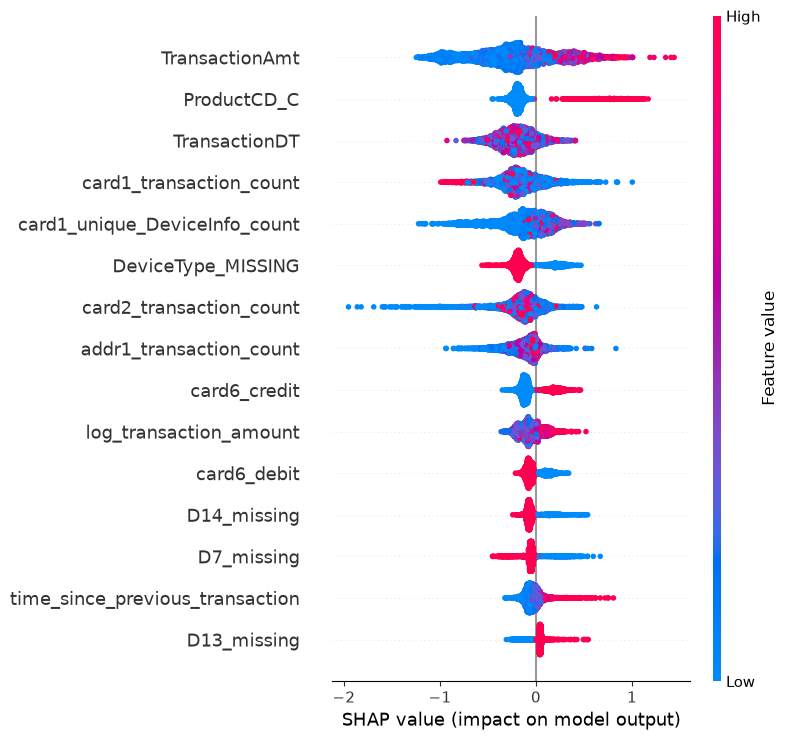

In [32]:
shap.summary_plot(shap_values, sample, max_display=15)

# SHAP Interpretation Insight
---------------------------

- TransactionAmt is the most influential feature in the SHAP summary,
  followed by ProductCD_C and TransactionDT.
- High transaction amounts generally push predictions toward higher
  fraud risk.
- ProductCD_C has a strong positive contribution for many transactions,
  confirming the signal observed during EDA.
- Entity features such as card1_transaction_count and
  card1_unique_DeviceInfo_count have meaningful model contributions,
  supporting the value of entity-based feature engineering.
- Several missingness indicators also influence predictions, confirming
  that missingness can contain useful information.
- SHAP shows that a feature's effect is not always one-directional;
  the same feature can increase or decrease fraud risk depending on
  the transaction context.
- SHAP provides directional and transaction-level explanations that
  cannot be obtained from XGBoost's built-in feature importance alone.

# Local SHAP

In [33]:
high_risk_idx = np.argmax(final_proba)
high_risk_score = final_proba[high_risk_idx]

print("Validation index:", high_risk_idx)
print("Fraud probability:", high_risk_score)
print("Actual label:", y_validation.iloc[high_risk_idx])

transaction = X_validation.iloc[[high_risk_idx]]
local_shap = explainer.shap_values(transaction)
print("Transaction shape:", transaction.shape)
print("SHAP shape:", local_shap.shape)

Validation index: 5441
Fraud probability: 0.9841562
Actual label: 1
Transaction shape: (1, 36)
SHAP shape: (1, 36)


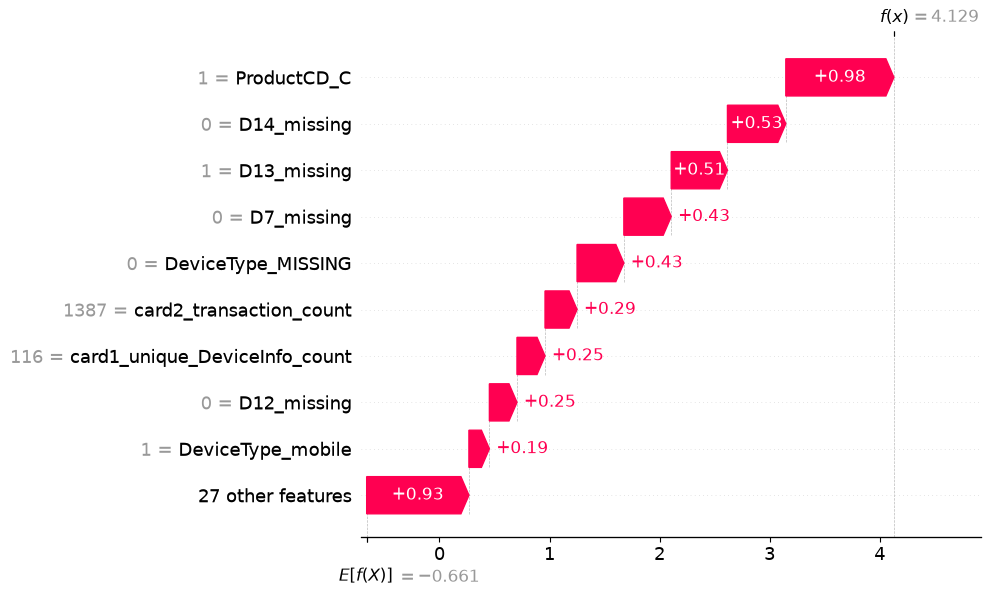

In [34]:
shap.waterfall_plot(
    shap.Explanation(
        values=local_shap[0],
        base_values=explainer.expected_value,
        data=transaction.iloc[0],
        feature_names=transaction.columns,
    )
)

# Local SHAP Interpretation
-------------------------

- The selected validation transaction was actually fraudulent and received
  a predicted fraud probability of approximately 98.42%.
- The SHAP waterfall starts from the model's baseline output (-0.661) and
  shows how individual feature values push the prediction toward or away
  from fraud.
- ProductCD_C is the strongest displayed positive contributor (+0.98).
- Several D-feature indicators also make substantial contributions,
  demonstrating that the specific missing/present pattern matters.
- card2_transaction_count and card1_unique_DeviceInfo_count contribute
  positively, showing that entity and relationship features can influence
  an individual fraud decision.
- The final SHAP output is 4.129 in the model's raw log-odds space,
  corresponding to a fraud probability of approximately 98.42%.
- SHAP explains model contribution, not causal relationships.

# SHAP EXPLAINER

In [35]:
shap_explainer = SHAPExplainer(final_xgb.model)
explanation = shap_explainer.explain(transaction, top_n=10)
explanation

,feature,value,shap_value,direction,abs_shap
0,ProductCD_C,1.0,0.981956,fraud,0.981956
1,D14_missing,0.0,0.530219,fraud,0.530219
2,D13_missing,1.0,0.510999,fraud,0.510999
3,D7_missing,0.0,0.430374,fraud,0.430374
4,DeviceType_MISSING,0.0,0.425077,fraud,0.425077
5,card2_transaction_count,1387.0,0.291062,fraud,0.291062
6,card1_unique_DeviceInfo_count,116.0,0.254843,fraud,0.254843
7,D12_missing,0.0,0.250698,fraud,0.250698
8,DeviceType_mobile,1.0,0.185916,fraud,0.185916
9,card1_transaction_count,741.0,0.174300,fraud,0.174300


In [36]:
fraud_reasons = explanation[explanation["shap_value"] > 0]
legitimate_reasons = explanation[explanation["shap_value"] < 0]

result = shap_explainer.explain_prediction(transaction, top_n=5)
print("Fraud probability:", result["fraud_probability"])
result["reasons"]

Fraud probability: 0.9841562


,feature,value,shap_value,direction,abs_shap
0,ProductCD_C,1.0,0.981956,fraud,0.981956
1,D14_missing,0.0,0.530219,fraud,0.530219
2,D13_missing,1.0,0.510999,fraud,0.510999
3,D7_missing,0.0,0.430374,fraud,0.430374
4,DeviceType_MISSING,0.0,0.425077,fraud,0.425077


In [37]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "extracted_data"

transactions = (
    pd.read_csv(DATA_PATH / "train_transaction.csv")
    .sort_values("TransactionDT")
    .reset_index(drop=True)
)

split_index = int(len(transactions) * 0.80)
validation_data = transactions.iloc[split_index:].copy()

train_identity = pd.read_csv(DATA_PATH / "train_identity.csv")
validation_data = validation_data.merge(
    train_identity[["TransactionID", "DeviceInfo", "DeviceType"]],
    on="TransactionID",
    how="left"
)

print("Validation rows:", len(validation_data))
print("X_validation rows:", len(X_validation))

Validation rows: 118108
X_validation rows: 118108


In [38]:
pred = (final_proba >= 0.5).astype(int)

tp_idx = np.where((y_validation.values == 1) & (pred == 1))[0][0]
tn_idx = np.where((y_validation.values == 0) & (pred == 0))[0][0]
fp_idx = np.where((y_validation.values == 0) & (pred == 1))[0][0]
fn_idx = np.where((y_validation.values == 1) & (pred == 0))[0][0]

print("TP:", tp_idx)
print("TN:", tn_idx)
print("FP:", fp_idx)
print("FN:", fn_idx)

TP: 75
TN: 1
FP: 3
FN: 0


In [39]:
tp_result = shap_explainer.explain_prediction(X_validation.iloc[[tp_idx]], top_n=5)
print("Fraud probability:", tp_result["fraud_probability"])
tp_result["reasons"]

Fraud probability: 0.5865556


,feature,value,shap_value,direction,abs_shap
0,ProductCD_C,1.0,0.829436,fraud,0.829436
1,card1_transaction_count,154.0,0.266786,fraud,0.266786
2,card1_DeviceInfo_transaction_count,42.0,-0.260697,legitimate,0.260697
3,D14_missing,0.0,0.213332,fraud,0.213332
4,DeviceInfo_unique_card1_count,4517.0,-0.204790,legitimate,0.204790


In [40]:
tn_result = shap_explainer.explain_prediction(X_validation.iloc[[tn_idx]], top_n=5)
print("Fraud probability:", tn_result["fraud_probability"])
tn_result["reasons"]

Fraud probability: 0.039498273


,feature,value,shap_value,direction,abs_shap
0,card2_transaction_count,83.000,-1.653252,legitimate,1.653252
1,ProductCD_C,1.000,0.364617,fraud,0.364617
2,card6_credit,0.000,-0.272804,legitimate,0.272804
3,TransactionAmt,52.811,-0.244484,legitimate,0.244484
4,D7_missing,1.000,-0.236585,legitimate,0.236585


In [41]:
fp_result = shap_explainer.explain_prediction(X_validation.iloc[[fp_idx]], top_n=5)
print("Fraud probability:", fp_result["fraud_probability"])
fp_result["reasons"]

Fraud probability: 0.7161525


,feature,value,shap_value,direction,abs_shap
0,ProductCD_C,1.0,0.952777,fraud,0.952777
1,D7_missing,0.0,0.477815,fraud,0.477815
2,card1_DeviceInfo_transaction_count,884.0,-0.360163,legitimate,0.360163
3,TransactionDT,12193040.0,-0.325057,legitimate,0.325057
4,card2_transaction_count,1984.0,0.268809,fraud,0.268809


In [42]:
fn_result = shap_explainer.explain_prediction(X_validation.iloc[[fn_idx]], top_n=5)
print("Validation index:", fn_idx)
print("Fraud probability:", fn_result["fraud_probability"])
print("Actual label:", y_validation.iloc[fn_idx])
fn_result["reasons"]

Validation index: 0
Fraud probability: 0.35869187
Actual label: 1


,feature,value,shap_value,direction,abs_shap
0,ProductCD_C,1.000,0.683648,fraud,0.683648
1,D7_missing,1.000,-0.356148,legitimate,0.356148
2,TransactionAmt,33.261,-0.341772,legitimate,0.341772
3,card1_transaction_count,997.000,-0.316278,legitimate,0.316278
4,DeviceType_MISSING,0.000,0.266674,fraud,0.266674


# False Negative SHAP Insight
---------------------------

- The selected transaction was actually fraudulent but received only a
  35.87% fraud probability, below the 0.5 threshold.
- ProductCD_C and the DeviceType state pushed the prediction toward fraud.
- D7_missing, TransactionAmt, and card1_transaction_count pushed the
  prediction toward legitimate and outweighed the stronger fraud signals.
- This shows that some fraudulent transactions can exhibit patterns that
  appear legitimate to the model.
- False-negative explanations can help identify missing or weak contextual
  signals, but a single transaction should not be used to justify changing
  the feature set.

# Aggregate error analysis.

In [43]:
tp = ((y_validation.values == 1) & (pred == 1)).sum()
tn = ((y_validation.values == 0) & (pred == 0)).sum()
fp = ((y_validation.values == 0) & (pred == 1)).sum()
fn = ((y_validation.values == 1) & (pred == 0)).sum()

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

TP: 1446
TN: 109886
FP: 4158
FN: 2618


In [44]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print("Precision:", precision)
print("Recall:", recall)
print("False Positive Rate:", fp / (fp + tn))
print("False Negative Rate:", fn / (fn + tp))

Precision: 0.2580299785867238
Recall: 0.3558070866141732
False Positive Rate: 0.036459612079548245
False Negative Rate: 0.6441929133858267


In [45]:
fp_data = validation_data.loc[(y_validation.values == 0) & (pred == 1)].copy()
fn_data = validation_data.loc[(y_validation.values == 1) & (pred == 0)].copy()

print("False Positives:", len(fp_data))
print("False Negatives:", len(fn_data))

False Positives: 4158
False Negatives: 2618


In [46]:
print("FALSE POSITIVE ProductCD:")
print(fp_data["ProductCD"].value_counts(normalize=True).round(4))

print("\nFALSE NEGATIVE ProductCD:")
print(fn_data["ProductCD"].value_counts(normalize=True).round(4))

FALSE POSITIVE ProductCD:
ProductCD
C    0.6893
W    0.1775
H    0.0536
S    0.0452
R    0.0344
Name: proportion, dtype: float64

FALSE NEGATIVE ProductCD:
ProductCD
W    0.6024
C    0.2292
R    0.0600
S    0.0577
H    0.0508
Name: proportion, dtype: float64


In [47]:
product_error = pd.DataFrame({
    "actual": validation_data["ProductCD"],
    "y_true": y_validation.values,
    "y_pred": pred
})

product_error["fp"] = ((product_error["y_true"] == 0) & (product_error["y_pred"] == 1)).astype(int)
product_error["fn"] = ((product_error["y_true"] == 1) & (product_error["y_pred"] == 0)).astype(int)

product_error = product_error.groupby("actual").agg(
    transactions=("y_true", "size"),
    fraud_count=("y_true", "sum"),
    fp=("fp", "sum"),
    fn=("fn", "sum"),
)

product_error["fp_rate"] = product_error["fp"] / (product_error["transactions"] - product_error["fraud_count"])
product_error["fn_rate"] = product_error["fn"] / product_error["fraud_count"]

product_error.sort_values("fn_rate", ascending=False)

,transactions,fraud_count,fp,fn,fp_rate,fn_rate
actual,,,,,,
W,93669,1810,738,1577,0.008034,0.871271
S,3501,183,188,151,0.056661,0.825137
H,3333,197,223,133,0.071110,0.675127
R,5496,257,143,157,0.027295,0.610895
C,12109,1617,2866,600,0.273161,0.371058


# ProductCD Error Analysis Insight
--------------------------------

- ProductCD=W has a very high false-negative rate (87.13%), indicating
  that the current model misses most fraud transactions in this category.
  Its false-positive rate is very low (0.80%), showing that the model is
  highly conservative for W.
- ProductCD=C has the highest false-positive rate (27.32%), indicating
  that the model frequently flags legitimate C transactions as fraud.
  Its false-negative rate is lower (37.11%) than W.
- This suggests category-dependent model behavior: the model is relatively
  aggressive for ProductCD=C and conservative for ProductCD=W.
- These results are hypotheses for further investigation, not evidence
  that ProductCD itself causes fraud or that category-specific thresholds
  should be deployed.

In [48]:
print("FALSE POSITIVE amount:")
print(fp_data["TransactionAmt"].describe())

print("\nFALSE NEGATIVE amount:")
print(fn_data["TransactionAmt"].describe())

FALSE POSITIVE amount:
count    4158.000000
mean      126.996804
std       196.484608
min         1.001000
25%        27.359000
50%        56.193000
75%       141.404000
max      4299.360000
Name: TransactionAmt, dtype: float64

FALSE NEGATIVE amount:
count    2618.000000
mean      160.997893
std       262.377312
min         2.292000
25%        39.000000
50%        77.000000
75%       165.135000
max      3133.060000
Name: TransactionAmt, dtype: float64


In [49]:
error_amount = pd.DataFrame({
    "ProductCD": validation_data["ProductCD"],
    "TransactionAmt": validation_data["TransactionAmt"],
    "y_true": y_validation.values,
    "y_pred": pred
})

error_amount["error_type"] = np.select(
    [
        (error_amount["y_true"] == 0) & (error_amount["y_pred"] == 1),
        (error_amount["y_true"] == 1) & (error_amount["y_pred"] == 0),
    ],
    ["FP", "FN"],
    default="Other",
)

error_amount = error_amount[error_amount["error_type"].isin(["FP", "FN"])]

error_amount.groupby(["ProductCD", "error_type"])["TransactionAmt"].agg(
    count="count",
    median="median",
    mean="mean",
    q75=lambda x: x.quantile(0.75),
).round(2)

count  median    mean     q75
ProductCD error_type                               
C         FN            600   31.23   45.48   53.87
          FP           2866   35.35   50.59   69.47
H         FN            133  100.00  110.98  150.00
          FP            223  150.00  163.30  150.00
R         FN            157  200.00  192.68  250.00
          FP            143  300.00  281.29  300.00
S         FN            151   30.00   38.62   50.00
          FP            188  106.00   92.56  110.00
W         FN           1577  107.95  217.73  226.00
          FP            738  311.94  391.63  554.00

# ProductCD + Transaction Amount Error Insight
---------------------------------------------

- ProductCD=W has a large false-negative population, and its missed fraud
  transactions have substantially lower transaction amounts than its false
  positives (median 107.95 vs 311.94).
- This suggests that lower-to-moderate amount W fraud transactions may be
  harder for the current model to distinguish from legitimate transactions.
- ProductCD=C has a very large false-positive population, but the median
  transaction amounts of C false positives and false negatives are similar
  (35.35 vs 31.23).
- Therefore, transaction amount alone does not explain the high C false
  positive rate.
- These patterns are hypotheses for further investigation and do not imply
  that transaction amount or ProductCD causally produces the model errors.

In [50]:
missing_columns = ["addr1", "addr2", "D7", "D12", "D13", "D14", "DeviceInfo"]

fp_mask = (y_validation.values == 0) & (pred == 1)
fn_mask = (y_validation.values == 1) & (pred == 0)

fp_missing = validation_data.loc[fp_mask, missing_columns].isna().mean()
fn_missing = validation_data.loc[fn_mask, missing_columns].isna().mean()

pd.DataFrame({
    "FP_missing_rate": fp_missing,
    "FN_missing_rate": fn_missing,
}).round(4)

,FP_missing_rate,FN_missing_rate
addr1,0.6878,0.2277
addr2,0.6878,0.2277
D7,0.4962,0.8323
D12,0.3175,0.7743
D13,0.3199,0.7781
D14,0.4291,0.7892
DeviceInfo,0.5486,0.6681


# Missingness Error Analysis Insight
----------------------------------

- False negatives show very high missingness in D7, D12, D13 and D14,
  with rates above 77% and D7 reaching 83.23%.
- This suggests that many missed fraud transactions share substantial
  D-field missingness patterns.
- False positives show much higher addr1/addr2 missingness (68.78%) than
  false negatives (22.77%).
- DeviceInfo is missing in both error groups, but more frequently among
  false negatives (66.81% vs 54.86%).
- These results support the importance of explicit missingness features,
  while also showing that different missingness patterns are associated
  with different model errors.
- These are error-analysis associations, not causal conclusions.

In [51]:
entity_features = [
    "card1_transaction_count",
    "card2_transaction_count",
    "addr1_transaction_count",
    "card1_DeviceInfo_transaction_count",
    "card1_unique_DeviceInfo_count",
    "DeviceInfo_unique_card1_count",
]

entity_error = pd.DataFrame({
    "FP": X_validation.loc[fp_mask, entity_features].median(),
    "FN": X_validation.loc[fn_mask, entity_features].median(),
})

entity_error

,FP,FN
card1_transaction_count,749.0,911.0
card2_transaction_count,3912.0,9019.0
addr1_transaction_count,53761.0,19826.0
card1_DeviceInfo_transaction_count,0.0,0.0
card1_unique_DeviceInfo_count,65.0,17.0
DeviceInfo_unique_card1_count,0.0,0.0


# Entity Error Analysis Insight
-----------------------------

- False negatives have higher median card1 and card2 transaction counts
  than false positives, with card2 showing the largest difference
  (9019 vs 3912).
- False positives have a much higher median addr1 transaction count
  (53761 vs 19826), suggesting that highly common address entities are
  more represented among incorrectly flagged legitimate transactions.
- card1_unique_DeviceInfo_count is also higher for false positives
  (65 vs 17), indicating greater device diversity in the FP group.
- The relationship-frequency features have zero medians in both error
  groups, so their usefulness cannot be determined from median values alone.
- These patterns show that entity behavior differs between FP and FN
  cases, but they represent associations rather than causal explanations.

In [52]:
error_proba = pd.DataFrame({
    "error_type": np.select([fp_mask, fn_mask], ["FP", "FN"], default="Other"),
    "probability": final_proba,
})

error_proba = error_proba[error_proba["error_type"].isin(["FP", "FN"])]
error_proba.groupby("error_type")["probability"].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
error_type,,,,,,,,
FN,2618.0,0.2356,0.1328,0.0064,0.1257,0.2173,0.3430,0.4998
FP,4158.0,0.6497,0.1112,0.5000,0.5585,0.6252,0.7245,0.9679


# Prediction Confidence Error Insight
-----------------------------------

- False negatives have a low probability distribution, with median fraud
  probability of 0.2173 and 75th percentile of 0.3430.
- False positives have a much higher probability distribution, with median
  0.6252 and 25th percentile of 0.5585.
- Therefore, most missed fraud cases are not simply borderline cases just
  below the 0.5 threshold.
- Likewise, many false positives receive relatively high fraud scores
  rather than being marginal threshold cases.
- This suggests that the current model has genuine feature-separation
  limitations in addition to threshold-selection limitations.
- Threshold tuning can change the precision-recall trade-off, but it is
  unlikely to eliminate the underlying FP/FN errors by itself.

# LIGHTGBM

In [53]:
lgbm_model = LightGBMModel(scale_pos_weight=13.730737)
print("LightGBM baseline initialized.")

LightGBM baseline initialized.


In [54]:
lgbm_model.train(X_train, y_train)

print("LightGBM baseline trained.")

LightGBM baseline trained.


In [55]:
lgbm_proba = lgbm_model.predict_proba(X_validation)

print("Predictions:", len(lgbm_proba))
print("Min:", lgbm_proba.min())
print("Max:", lgbm_proba.max())

Predictions: 118108
Min: 0.003273892011444071
Max: 0.974306732527491


In [56]:
lgbm_pr_auc = average_precision_score(y_validation, lgbm_proba)
lgbm_roc_auc = roc_auc_score(y_validation, lgbm_proba)

print("LightGBM PR-AUC:", lgbm_pr_auc)
print("LightGBM ROC-AUC:", lgbm_roc_auc)

LightGBM PR-AUC: 0.22141859801529934
LightGBM ROC-AUC: 0.8142024344640983


In [57]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

lgbm_threshold_results = []

for threshold in thresholds:
    pred = (lgbm_proba >= threshold).astype(int)

    lgbm_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, pred),
        "recall": recall_score(y_validation, pred),
        "f1": f1_score(y_validation, pred)
    })

lgbm_threshold_results = pd.DataFrame(
    lgbm_threshold_results
).sort_values("f1", ascending=False).reset_index(drop=True)

lgbm_threshold_results

,threshold,precision,recall,f1
0,0.6,0.247786,0.351132,0.290543
1,0.7,0.312293,0.255659,0.281153
2,0.5,0.200335,0.441437,0.275597
3,0.4,0.157823,0.543799,0.244645
4,0.8,0.403356,0.159695,0.228803
5,0.3,0.105662,0.680118,0.182907
6,0.2,0.067574,0.840305,0.125089
7,0.1,0.045230,0.950295,0.086351
8,0.9,0.586667,0.032480,0.061553


## LightGBM Baseline — Threshold Analysis Insight

- LightGBM achieved a PR-AUC of **0.2214** and ROC-AUC of **0.8142** on the future-time validation set.
- Among the tested thresholds, **0.6** produced the highest F1 score.
- At threshold 0.6:
  - Precision = **24.78%**
  - Recall = **35.11%**
  - F1 = **29.05%**
- Lower thresholds improve recall but reduce precision.
- Higher thresholds improve precision but reduce recall.
- Threshold 0.7 gives higher precision (**31.23%**) but lower recall (**25.57%**).
- Therefore, threshold selection involves a precision-recall trade-off.
- **0.6 is the best tested LightGBM threshold by F1**, but it is not yet the final production threshold.
- LightGBM performs very similarly to XGBoost but remains slightly behind XGBoost on the current validation set.

In [58]:
# Tune num_leaves
leaf_results = []

for leaves in [15, 31, 63]:
    model = LightGBMModel(
        scale_pos_weight=13.730737,
        n_estimators=300,
        num_leaves=leaves,
        max_depth=-1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1
    )

    model.train(X_train, y_train)
    prob = model.predict_proba(X_validation)

    leaf_results.append({
        "num_leaves": leaves,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob)
    })

leaf_results = pd.DataFrame(leaf_results).sort_values(
    "pr_auc", ascending=False
).reset_index(drop=True)

leaf_results

,num_leaves,pr_auc,roc_auc
0,63,0.228194,0.821265
1,31,0.221419,0.814202
2,15,0.206197,0.801046


In [59]:
# Tune min_child_samples
child_results = []

for samples in [20, 50, 100]:
    model = LightGBMModel(
        scale_pos_weight=13.730737,
        n_estimators=300,
        num_leaves=63,
        max_depth=-1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1
    )
    model.model.set_params(min_child_samples=samples)

    model.train(X_train, y_train)
    prob = model.predict_proba(X_validation)

    child_results.append({
        "min_child_samples": samples,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob)
    })

child_results = pd.DataFrame(child_results).sort_values(
    "pr_auc", ascending=False
).reset_index(drop=True)

child_results

,min_child_samples,pr_auc,roc_auc
0,50,0.228561,0.821206
1,20,0.228194,0.821265
2,100,0.223500,0.824245


In [60]:
# test learning rate + number of estimators
learning_results = []

for lr, n in [(0.03, 500), (0.05, 300), (0.10, 200)]:
    model = LightGBMModel(
        scale_pos_weight=13.730737,
        n_estimators=n,
        num_leaves=63,
        max_depth=-1,
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=1
    )
    model.model.set_params(min_child_samples=50)

    model.train(X_train, y_train)
    prob = model.predict_proba(X_validation)

    learning_results.append({
        "learning_rate": lr,
        "n_estimators": n,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob)
    })

learning_results = pd.DataFrame(learning_results).sort_values(
    "pr_auc", ascending=False
).reset_index(drop=True)

learning_results

,learning_rate,n_estimators,pr_auc,roc_auc
0,0.10,200,0.230965,0.820057
1,0.03,500,0.230461,0.826214
2,0.05,300,0.228561,0.821206


In [61]:
# test feature and row sampling
sampling_results = []

for subsample in [0.7, 0.8, 1.0]:
    for colsample in [0.7, 0.8, 1.0]:
        model = LightGBMModel(
            scale_pos_weight=13.730737,
            n_estimators=200,
            num_leaves=63,
            learning_rate=0.10,
            subsample=subsample,
            colsample_bytree=colsample,
            reg_alpha=0,
            reg_lambda=1
        )
        model.model.set_params(min_child_samples=50)

        model.train(X_train, y_train)
        prob = model.predict_proba(X_validation)

        sampling_results.append({
            "subsample": subsample,
            "colsample_bytree": colsample,
            "pr_auc": average_precision_score(y_validation, prob),
            "roc_auc": roc_auc_score(y_validation, prob)
        })

sampling_results = pd.DataFrame(sampling_results).sort_values(
    "pr_auc", ascending=False
).reset_index(drop=True)

sampling_results

,subsample,colsample_bytree,pr_auc,roc_auc
0,0.7,0.8,0.230965,0.820057
1,1.0,0.8,0.230965,0.820057
2,0.8,0.8,0.230965,0.820057
3,1.0,1.0,0.222658,0.816547
4,0.7,1.0,0.222658,0.816547
5,0.8,1.0,0.222658,0.816547
6,0.7,0.7,0.218369,0.824890
7,0.8,0.7,0.218369,0.824890
8,1.0,0.7,0.218369,0.824890


In [62]:
# L2 regularization pass
l2_results = []

for reg_lambda in [1, 5, 10]:
    model = LightGBMModel(
        scale_pos_weight=13.730737,
        n_estimators=200,
        num_leaves=63,
        learning_rate=0.10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=reg_lambda
    )
    model.model.set_params(min_child_samples=50)

    model.train(X_train, y_train)
    prob = model.predict_proba(X_validation)

    l2_results.append({
        "reg_lambda": reg_lambda,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob)
    })

l2_results = pd.DataFrame(l2_results).sort_values(
    "pr_auc", ascending=False
).reset_index(drop=True)
 
l2_results

,reg_lambda,pr_auc,roc_auc
0,5,0.234850,0.826183
1,1,0.230965,0.820057
2,10,0.227803,0.818671


In [63]:
# L1 regularization pass
l1_results = []

for alpha in [0, 0.1, 0.5, 1]:
    model = LightGBMModel(
        scale_pos_weight=13.730737,
        n_estimators=200,
        num_leaves=63,
        learning_rate=0.10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=alpha,
        reg_lambda=5
    )
    model.model.set_params(min_child_samples=50)

    model.train(X_train, y_train)
    prob = model.predict_proba(X_validation)

    l1_results.append({
        "reg_alpha": alpha,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob)
    })

l1_results = pd.DataFrame(l1_results).sort_values(
    "pr_auc", ascending=False
).reset_index(drop=True)

l1_results

,reg_alpha,pr_auc,roc_auc
0,0.0,0.234850,0.826183
1,1.0,0.227431,0.822921
2,0.5,0.223757,0.823558
3,0.1,0.223742,0.824262


In [64]:
# scale_pos_weight
weight_results = []

for factor in [0.5, 1.0, 1.5, 2.0]:
    model = LightGBMModel(
        scale_pos_weight=13.730737 * factor,
        n_estimators=200,
        num_leaves=63,
        learning_rate=0.10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0,
        reg_lambda=5
    )
    model.model.set_params(min_child_samples=50)

    model.train(X_train, y_train)
    prob = model.predict_proba(X_validation)

    weight_results.append({
        "weight_factor": factor,
        "scale_pos_weight": 13.730737 * factor,
        "pr_auc": average_precision_score(y_validation, prob),
        "roc_auc": roc_auc_score(y_validation, prob)
    })

weight_results = pd.DataFrame(weight_results).sort_values(
    "pr_auc", ascending=False
).reset_index(drop=True)

weight_results

,weight_factor,scale_pos_weight,pr_auc,roc_auc
0,0.5,6.865368,0.237115,0.821670
1,1.0,13.730737,0.234850,0.826183
2,2.0,27.461474,0.218514,0.816966
3,1.5,20.596106,0.216581,0.821832


In [65]:
# Final Light GBM
final_lgbm = LightGBMModel(
    scale_pos_weight=6.865368,
    n_estimators=200,
    num_leaves=63,
    learning_rate=0.10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=5
)

final_lgbm.model.set_params(min_child_samples=50)

final_lgbm.train(X_train, y_train)

print("Final LightGBM candidate trained.")

Final LightGBM candidate trained.


In [66]:
final_lgbm_proba = final_lgbm.predict_proba(X_validation)

print("Predictions:", len(final_lgbm_proba))
print("Min:", final_lgbm_proba.min())
print("Max:", final_lgbm_proba.max())

Predictions: 118108
Min: 0.0008786444704678965
Max: 0.9882929575451598


In [67]:
final_lgbm_pr_auc = average_precision_score(y_validation, final_lgbm_proba)
final_lgbm_roc_auc = roc_auc_score(y_validation, final_lgbm_proba)

print("PR-AUC:", final_lgbm_pr_auc)
print("ROC-AUC:", final_lgbm_roc_auc)

PR-AUC: 0.23711512899774836
ROC-AUC: 0.8216698887475258


In [68]:
# final LightGBM threshold analysis.
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

final_lgbm_thresholds = []

for threshold in thresholds:
    pred = (final_lgbm_proba >= threshold).astype(int)

    final_lgbm_thresholds.append({
        "threshold": threshold,
        "precision": precision_score(y_validation, pred),
        "recall": recall_score(y_validation, pred),
        "f1": f1_score(y_validation, pred)
    })

final_lgbm_thresholds = pd.DataFrame(
    final_lgbm_thresholds
).sort_values("f1", ascending=False).reset_index(drop=True)

final_lgbm_thresholds

,threshold,precision,recall,f1
0,0.4,0.243998,0.400098,0.303132
1,0.5,0.284901,0.307825,0.295920
2,0.3,0.195862,0.498524,0.281233
3,0.6,0.347005,0.235236,0.280393
4,0.2,0.141543,0.632136,0.231296
5,0.7,0.431941,0.157726,0.231074
6,0.1,0.074995,0.812254,0.137313
7,0.8,0.523050,0.072589,0.127485
8,0.9,0.717949,0.013780,0.027040


In [69]:
# MULTI LAYER PERCEPTRON
mlp_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("MLP pos_weight:", mlp_pos_weight)

MLP pos_weight: 27.46147358274595


In [70]:
mlp_model = MLPModel(
    input_dim=X_train.shape[1],
    pos_weight=mlp_pos_weight
)

print("MLP initialized.")

MLP initialized.


In [71]:
mlp_model.train(
    X_train,
    y_train,
    epochs=10,
    batch_size=1024
)

Epoch 1/10 - Loss: 1.1200
Epoch 2/10 - Loss: 1.0799
Epoch 3/10 - Loss: 1.0678
Epoch 4/10 - Loss: 1.0605
Epoch 5/10 - Loss: 1.0541
Epoch 6/10 - Loss: 1.0488
Epoch 7/10 - Loss: 1.0448
Epoch 8/10 - Loss: 1.0405
Epoch 9/10 - Loss: 1.0369
Epoch 10/10 - Loss: 1.0348


In [72]:
mlp_proba = mlp_model.predict_proba(X_validation)

print("Predictions:", len(mlp_proba))
print("Min:", mlp_proba.min())
print("Max:", mlp_proba.max())

Predictions: 118108
Min: 0.073713854
Max: 0.9969662


In [73]:
mlp_pr_auc = average_precision_score(y_validation, mlp_proba)
mlp_roc_auc = roc_auc_score(y_validation, mlp_proba)

print("MLP PR-AUC:", mlp_pr_auc)
print("MLP ROC-AUC:", mlp_roc_auc)

MLP PR-AUC: 0.16846836677552182
MLP ROC-AUC: 0.7655334783066184


## MLP Baseline — Conclusion

- The MLP achieved a PR-AUC of **0.17384** and ROC-AUC of **0.76639** on the future-time validation set.
- MLP performs better than Logistic Regression but substantially worse than XGBoost and LightGBM.
- Current model ranking by PR-AUC:
  - **LightGBM:** 0.23712
  - **XGBoost:** 0.22604
  - **MLP:** 0.17384
  - **Logistic Regression:** 0.15376
- The MLP will not be tuned further at this stage because its baseline performance is significantly below the boosted-tree models.
- LightGBM remains the current leading model.

# Global SHAP for the final LightGBM model

In [74]:
lgbm_explainer = shap.TreeExplainer(final_lgbm.model)

print("LightGBM SHAP explainer created.")

LightGBM SHAP explainer created.


In [75]:
lgbm_sample = X_validation.sample(5000, random_state=42)
lgbm_shap_values = lgbm_explainer.shap_values(lgbm_sample)

print("SHAP shape:", lgbm_shap_values.shape)

SHAP shape: (5000, 36)


C:\Users\Manojit Khatua\AI ENGINEERING\trace-ai\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
shap.summary_plot(lgbm_shap_values,lgbm_sample,max_display=15)

## LightGBM Global SHAP Insight

- TransactionAmt is the most influential feature in the final LightGBM model.
- card1_unique_DeviceInfo_count is the second most influential feature,
  showing that card-device relationship behavior provides important fraud
  signal.
- ProductCD_C remains a strong fraud-related feature, although LightGBM
  relies on it less overwhelmingly than the earlier XGBoost model.
- Entity-frequency features such as card1_transaction_count and
  card2_transaction_count contribute substantially to the model.
- TransactionDT provides a contextual temporal signal rather than a simple
  one-directional relationship with fraud.
- DeviceType_MISSING and other missingness features remain influential,
  confirming that missingness contains predictive information.
- The SHAP analysis shows that LightGBM uses transaction, categorical,
  entity, relationship, temporal, and missingness signals together.
- SHAP indicates model contribution and direction, not causality.

# LightGBM Local SHAP

In [77]:
lgbm_explainer = shap.TreeExplainer(final_lgbm.model)
lgbm_pred = (final_lgbm_proba >= 0.4).astype(int)

In [78]:
lgbm_tp = np.where((y_validation.values == 1) & (lgbm_pred == 1))[0][0]
lgbm_tn = np.where((y_validation.values == 0) & (lgbm_pred == 0))[0][0]
lgbm_fp = np.where((y_validation.values == 0) & (lgbm_pred == 1))[0][0]
lgbm_fn = np.where((y_validation.values == 1) & (lgbm_pred == 0))[0][0]

print("TP:", lgbm_tp)
print("TN:", lgbm_tn)
print("FP:", lgbm_fp)
print("FN:", lgbm_fn)

TP: 72
TN: 1
FP: 3
FN: 0


In [ ]:
# True Positive
lgbm_tp_result = shap_explainer.explain_prediction(X_validation.iloc[[lgbm_tp]],top_n=5)
print("Fraud probability:", lgbm_tp_result["fraud_probability"])
lgbm_tp_result["reasons"]

In [ ]:
# True Negative
lgbm_tn_result = shap_explainer.explain_prediction(X_validation.iloc[[lgbm_tn]],top_n=5)

print("Fraud probability:", lgbm_tn_result["fraud_probability"])
lgbm_tn_result["reasons"]

In [ ]:
# FALSE POSITIVE
lgbm_fp_result = shap_explainer.explain_prediction(X_validation.iloc[[lgbm_fp]],top_n=5)
print("Fraud probability:", lgbm_fp_result["fraud_probability"])
lgbm_fp_result["reasons"]

## LightGBM False Positive — Local SHAP Insight

- The selected transaction was legitimate but received a fraud probability of approximately 71.62%.
- ProductCD_C was the strongest positive contributor, followed by the D7 state and card2 transaction frequency.
- card1_DeviceInfo_transaction_count and TransactionDT pushed the prediction toward legitimate, but their effects were not sufficient to reduce the score below the 0.40 threshold.
- The explanation shows that multiple fraud-like signals can combine to produce a high fraud score even for a legitimate transaction.
- This false positive is also consistent with the earlier XGBoost explanation, suggesting that some model errors arise from the underlying feature patterns rather than from a single algorithm.
- SHAP explains model contribution, not causality.

In [ ]:
# FALSE NEGATIVE
lgbm_fn_result = shap_explainer.explain_prediction(X_validation.iloc[[lgbm_fn]],top_n=5)

print("Fraud probability:", lgbm_fn_result["fraud_probability"])
lgbm_fn_result["reasons"]

## LightGBM False Negative — Local SHAP Insight

- The selected transaction was actually fraudulent but received a fraud probability of approximately 35.87%, below the current 0.40 threshold.
- ProductCD_C and the DeviceType state pushed the prediction toward fraud.
- D7_missing, TransactionAmt, and card1_transaction_count pushed the prediction toward legitimate.
- The legitimate-oriented contributions outweighed the fraud-oriented contributions, resulting in a false negative.
- This demonstrates that some fraud transactions contain strong legitimate-looking patterns that make them difficult for the model to distinguish.
- SHAP explains model contribution, not causality.

In [ ]:
comparison = pd.DataFrame({
    "model": ["Logistic Regression","XGBoost","LightGBM","MLP"],
    "pr_auc": [0.1537619253,0.226038,0.2371151290,0.1738432505],
    "roc_auc": [0.7486762884,0.820047,0.8216698887,0.7663906079],
    "best_f1": [0.214941,0.299131,0.303132,np.nan]})

comparison.sort_values("pr_auc", ascending=False).reset_index(drop=True)

## Final Model Comparison

All models were evaluated using the same 36-feature representation and the same future-time validation set.

| Model | PR-AUC | ROC-AUC | Best Tested F1 |
|---|---:|---:|---:|
| Logistic Regression | 0.15376 | 0.74868 | 0.21494 |
| XGBoost | 0.22604 | 0.82005 | 0.29913 |
| **LightGBM** | **0.23712** | **0.82167** | **0.30313** |
| MLP | 0.17384 | 0.76639 | — |

### Conclusion

LightGBM is the strongest model among the evaluated candidates based primarily on PR-AUC. It also achieves the highest ROC-AUC and best tested F1 among the models for which threshold analysis was completed.

LightGBM therefore becomes the current final model candidate for TRACE.

In [84]:
# LOCKING THE LIGHTGBM MODEL
MODEL_PATH = PROJECT_ROOT / "models"
MODEL_PATH.mkdir(parents=True, exist_ok=True)

In [85]:
joblib.dump(
    final_lgbm.model,
    MODEL_PATH / "lightgbm_final.pkl"
)

['C:\\Users\\Manojit Khatua\\AI ENGINEERING\\trace-ai\\models\\lightgbm_final.pkl']

In [86]:
with open(MODEL_PATH / "lightgbm_config.json", "w") as f:
    json.dump({
        "threshold": 0.4,
        "pr_auc": final_lgbm_pr_auc,
        "roc_auc": final_lgbm_roc_auc,
        "num_leaves": 63,
        "min_child_samples": 50,
        "learning_rate": 0.10,
        "n_estimators": 200,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0,
        "reg_lambda": 5,
        "scale_pos_weight": 6.865368
    }, f, indent=2)

print("LightGBM configuration saved.")

LightGBM configuration saved.


In [87]:
print((MODEL_PATH / "lightgbm_final.pkl").exists())
print((MODEL_PATH / "lightgbm_config.json").exists())

True
True


In [88]:
predictor = FraudPredictor(
    MODEL_PATH / "lightgbm_final.pkl",
    MODEL_PATH / "lightgbm_config.json"
)

print("Predictor loaded.")
print("Threshold:", predictor.threshold)

NameError: name 'FraudPredictor' is not defined

In [ ]:
test_prediction = predictor.predict(X_validation.head(5))
test_prediction

In [ ]:
importlib.reload(predictor_module)
FraudPredictor = predictor_module.FraudPredictor
print("FraudPredictor reloaded.")

In [ ]:
predictor = FraudPredictor(
    MODEL_PATH / "lightgbm_final.pkl",
    MODEL_PATH / "lightgbm_config.json",
    MODEL_PATH / "preprocessing"
)

print("Predictor loaded.")

In [ ]:
test_transaction = validation_data.iloc[[0]].copy()

result = predictor.predict(test_transaction)

print("Probability:", result["fraud_probability"])
print("Prediction:", result["prediction"])
print("Threshold:", result["threshold"])

In [ ]:
pd.DataFrame(result["reasons"])

In [ ]:
test_transaction = validation_data.iloc[[0]].copy()
result = predictor.predict(test_transaction)
print(result)

In [ ]:
# saved predictor vs direct LightGBM prediction on the exact same transaction
# Direct prediction from the already-prepared 36-feature validation row
direct_probability = float(
    final_lgbm.model.predict_proba(
        X_validation.iloc[[0]]
    )[:, 1][0]
)

# Prediction through our new predictor pipeline
pipeline_result = predictor.predict(
    validation_data.iloc[[0]].copy()
)

pipeline_probability = pipeline_result["fraud_probability"]

print("Direct model probability :", direct_probability)
print("Predictor probability    :", pipeline_probability)
print("Difference               :", abs(direct_probability - pipeline_probability))

In [ ]:
# Confusion MAtrix
threshold = 0.4

y_pred_cost = (final_lgbm_proba >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_validation,y_pred_cost).ravel()

print("Threshold:", threshold)
print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

In [ ]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("Precision:", precision)
print("Recall:", recall)
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

In [ ]:
# Bussiness cost
FP_COST = 1
FN_COST = 1

total_cost = (fp * FP_COST +fn * FN_COST)

print("Total error cost:", total_cost)

In [ ]:
# Different cost ratio
cost_ratios = [1, 2, 5, 10]

thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for ratio in cost_ratios:
    for threshold in thresholds:

        y_pred = (final_lgbm_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_validation,y_pred).ravel()

        total_cost = fp + (fn * ratio)

        results.append({"fn_cost_ratio": ratio,"threshold": threshold,"FP": fp,"FN": fn,"total_cost": total_cost})

cost_analysis = pd.DataFrame(results)

cost_analysis.sort_values(["fn_cost_ratio", "total_cost"]).groupby("fn_cost_ratio").head(1)

In [ ]:
# amount-weighted cost analysis
amount_cost_analysis = []

thresholds = np.arange(0.1, 1.0, 0.1)

for threshold in thresholds:

    y_pred = (final_lgbm_proba >= threshold).astype(int)n

    temp = validation_data[["TransactionAmt", "isFraud"]].copy()
    temp["prediction"] = y_pred

    # False Positive:
    # actual legitimate, predicted fraud
    fp_amount = temp.loc[
        (temp["isFraud"] == 0) & (temp["prediction"] == 1),
        "TransactionAmt"
    ].sum()

    # False Negative:
    # actual fraud, predicted legitimate
    fn_amount = temp.loc[
        (temp["isFraud"] == 1) & (temp["prediction"] == 0),
        "TransactionAmt"
    ].sum()

    amount_cost_analysis.append({3"threshold": threshold,"FP_amount": fp_amount,"FN_amount": fn_amount,"total_amount_exposure": fp_amount + fn_amount})

amount_cost_df = pd.DataFrame(amount_cost_analysis)

amount_cost_df

In [ ]:
# amount-weighted FP/FN cost-ratio analysis.
amount_ratio_results = []

thresholds = np.arange(0.1, 1.0, 0.1)
fn_cost_ratios = [1, 2, 5, 10]

for ratio in fn_cost_ratios:

    for threshold in thresholds:

        y_pred = (final_lgbm_proba >= threshold).astype(int)

        temp = validation_data[["TransactionAmt", "isFraud"]].copy()
        temp["prediction"] = y_pred

        fp_amount = temp.loc[
            (temp["isFraud"] == 0) & (temp["prediction"] == 1),
            "TransactionAmt"
        ].sum()

        fn_amount = temp.loc[
            (temp["isFraud"] == 1) & (temp["prediction"] == 0),
            "TransactionAmt"
        ].sum()

        total_cost = fp_amount + (fn_amount * ratio)

        amount_ratio_results.append({
            "fn_cost_ratio": ratio,
            "threshold": threshold,
            "FP_amount": fp_amount,
            "FN_amount": fn_amount,
            "total_cost": total_cost
        })

amount_ratio_df = pd.DataFrame(amount_ratio_results)

best_amount_cost = (
    amount_ratio_df
    .sort_values(["fn_cost_ratio", "total_cost"])
    .groupby("fn_cost_ratio")
    .head(1)
    .reset_index(drop=True)
)

best_amount_cost

# ## Amount-Weighted Business Cost Analysis

The threshold was evaluated using transaction amount as an exposure measure.
False-positive and false-negative exposure were weighted under multiple
false-negative cost assumptions.

| FN Cost Ratio | Best Threshold |
|---:|---:|
| 1× | 0.8 |
| 2× | 0.7 |
| 5× | 0.5 |
| 10× | 0.4 |

As the relative cost of missed fraud increases, the preferred threshold
decreases. This demonstrates the trade-off between payment friction caused
by false positives and financial exposure caused by false negatives.

The final operating threshold should therefore be treated as a configurable
business-policy parameter rather than an immutable model property.